Benjamin Arnold, 09/06/2026, Lab 2-- Energy-Tracking Projectile

Part A: Adding Energy Tracking

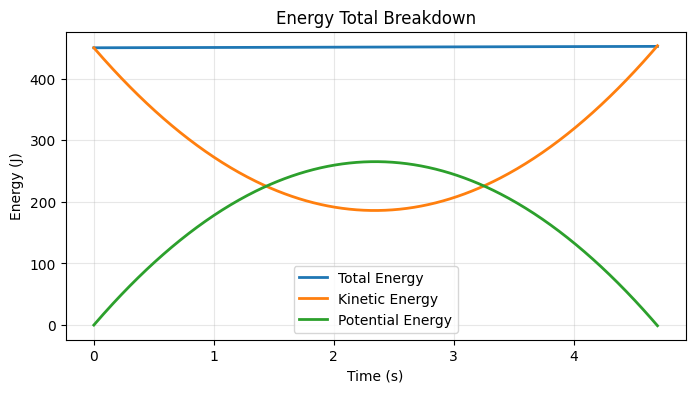

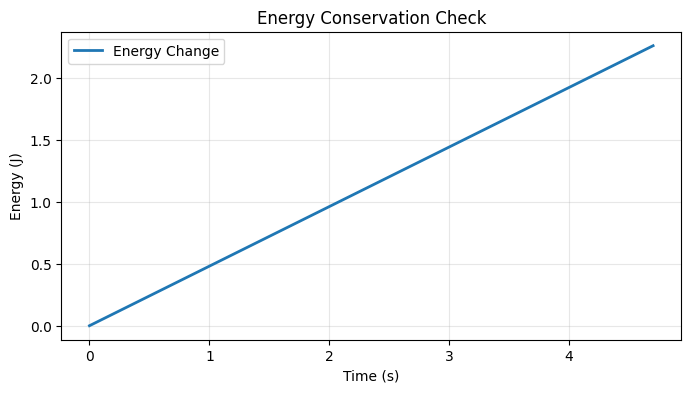

Energy Percentage Gain: 0.5000532011290287%


In [15]:
import numpy as np
import matplotlib.pyplot as plt

#Useful Constants--------------------------------------------------------------------------------------
time_step=0.01
initial_velocity=30.0
initial_angle=50.0
g=9.81
m=1.0

#Function for simulating constants in 2d---------------------------------------------------------------
def simulate_projectile_2d(v0,theta_deg,dt,g=g,m=m):
    ay,ax=-g,0
    vx=v0*np.cos(theta_deg*np.pi/180)
    vy=v0*np.sin(theta_deg*np.pi/180)

    x,y,t=0.0,0.0,0.0

    KE=(0.5*m)*(vx**2+vy**2)
    PE=(m*g)*y
    E=KE+PE
    
    t_arr,x_arr,y_arr,vy_arr,vx_arr,E_arr,KE_arr,PE_arr=[t],[x],[y],[vy],[vx],[E],[KE],[PE]

    while (y>=0):
        x=x+vx*dt
        y=y+vy*dt
        vx=vx+ax*dt
        vy=vy+ay*dt
        t=t+dt

        KE=(0.5*m)*(vx**2+vy**2)
        PE=(m*g)*y
        E=KE+PE

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vy_arr.append(vy)
        vx_arr.append(vx)
        E_arr.append(E)
        KE_arr.append(KE)
        PE_arr.append(PE)
    return t_arr,x_arr,y_arr,vx_arr,vy_arr,E_arr,KE_arr,PE_arr

t,x,y,vx,vy,E,KE,PE=simulate_projectile_2d(initial_velocity,initial_angle,time_step,g=g,m=m)

plt.figure(figsize=(8, 4))
plt.plot(t, E, linewidth=2, label='Total Energy')
plt.plot(t, KE, linewidth=2, label='Kinetic Energy')
plt.plot(t, PE, linewidth=2, label='Potential Energy')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy Total Breakdown')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, (E-E[0]), linewidth=2, label='Energy Change')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy Conservation Check')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'Energy Percentage Gain: {((E[-1]-E[0])/E[-1])*100}%')


Interpretation: With the Euler Method, and without drag, the energy drifts upward linearly, gaining about half a percent of error every 5 seconds or so. The drift seems to be perfectly constant, and does not accelerate.

Part B: Euler Vs. Euler-Cromer

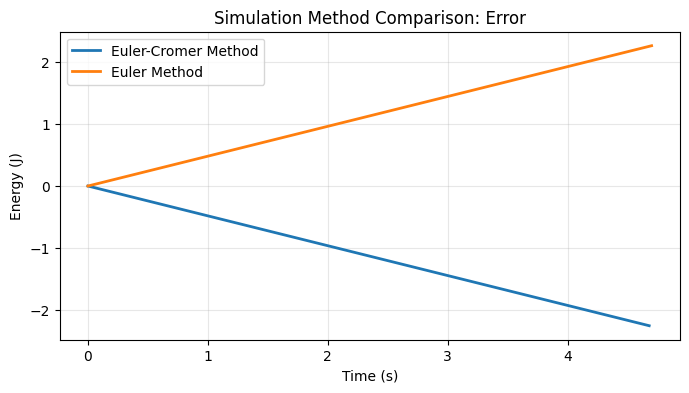

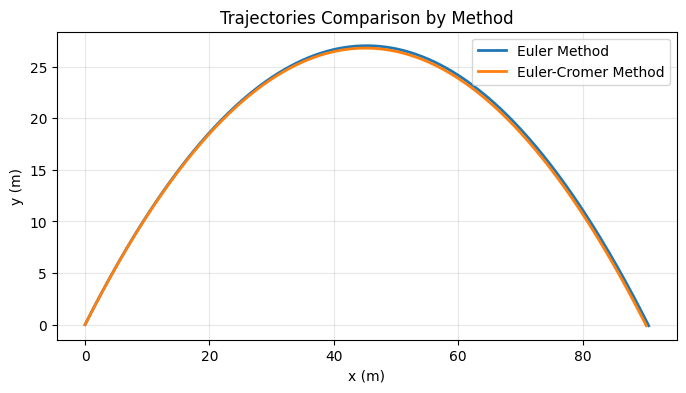

The range for the Euler method is 90.63305296580204 meters, and the range for the Euler-Cromer method is 90.24738039999012 meters. A difference of 0.385672565811916 meters.


In [27]:
import numpy as np
import matplotlib.pyplot as plt

#Useful Constants--------------------------------------------------------------------------------------
time_step=0.01
initial_velocity=30.0
initial_angle=50.0
g=9.81
m=1.0

#Function for simulating trajectories in 2d, with energy tracking.
#The method is a Boolean: input 1 for Euler-Cromer, 0 for Euler.
def simulate(method,v0,theta_deg,dt,g=g,m=m):
    ay,ax=-g,0
    vx=v0*np.cos(theta_deg*np.pi/180)
    vy=v0*np.sin(theta_deg*np.pi/180)

    x,y,t=0.0,0.0,0.0

    KE=(0.5*m)*(vx**2+vy**2)
    PE=(m*g)*y
    E=KE+PE
    
    t_arr,x_arr,y_arr,vy_arr,vx_arr,E_arr,KE_arr,PE_arr=[t],[x],[y],[vy],[vx],[E],[KE],[PE]

    while (y>=0):
        if (method==1):
            vx=vx+ax*dt
            vy=vy+ay*dt
            x=x+vx*dt
            y=y+vy*dt
        elif(method==0):
            x=x+vx*dt
            y=y+vy*dt
            vx=vx+ax*dt
            vy=vy+ay*dt

        KE=(0.5*m)*(vx**2+vy**2)
        PE=(m*g)*y
        E=KE+PE

        t=t+dt

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vy_arr.append(vy)
        vx_arr.append(vx)
        E_arr.append(E)
        KE_arr.append(KE)
        PE_arr.append(PE)
    return t_arr,x_arr,y_arr,vx_arr,vy_arr,E_arr,KE_arr,PE_arr

t1,x1,y1,vx1,vy1,E1,KE1,PE1=simulate(1,initial_velocity,initial_angle,time_step,g=g,m=m)
t,x,y,vx,vy,E,KE,PE=simulate(0,initial_velocity,initial_angle,time_step,g=g,m=m)

plt.figure(figsize=(8, 4))
plt.plot(t1, (E1-E1[0]), linewidth=2, label='Euler-Cromer Method')
plt.plot(t, (E-E[0]), linewidth=2, label='Euler Method')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Simulation Method Comparison: Error')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(x, y, linewidth=2, label='Euler Method')
plt.plot(x1, y1, linewidth=2, label='Euler-Cromer Method')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajectories Comparison by Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'The range for the Euler method is {np.max(x)} meters, and the range for the Euler-Cromer method is {np.max(x1)} meters.\
 A difference of {np.max(x)-np.max(x1)} meters.')

Interpretation: In the actual physical world, position and velocity "update" at the same time. But when simulating, we have to choose a discrete time-step by which to progress our simulation, which introduces a problem: should we update velocity or position first? If we choose to update position first (Euler Method), then we use the old velocity, which overshoots systematically because in reality the velocity is continually decreasing (due to gravity in this case). But if we choose to update velocity first (Euler-Cromer Method), then we choose the new velocity, which undershoots systematically for the same reason but opposite sign. 